In [1]:
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.diagnostics as diag
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 1.0
t_end = 6.0
cfl_safety = 1.0 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/orzag-tang-3D/"

#we will use hyperviscosity
visc=1e-8
res=1e-8
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)


#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
psi = (jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)) * jnp.cos(z_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 1


In [7]:
_=jr.simulate(state,kgrid,params,t_snap=t_snap,t_end=t_end,mngr=mngr,shardings=shardings)

Saving initial state as snapshot 0
---COMPILING rk_advance---
Saving snapshot 1 at t = 1.00468568217417
---COMPILING rk_advance---
Saving snapshot 2 at t = 2.011341579545504
Saving snapshot 3 at t = 3.0202981616521645
Saving snapshot 4 at t = 4.021602896961123
Saving snapshot 5 at t = 5.030136862354452
Saving snapshot 6 at t = 6.036193894247471
Ending simulation at t = 6.036193894247471


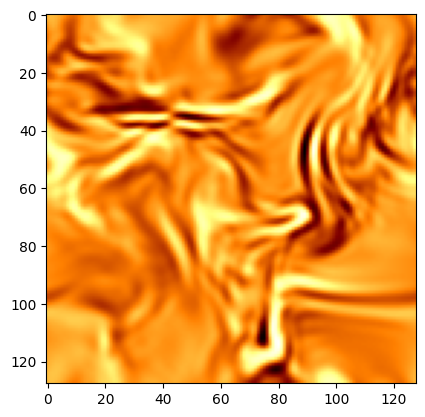

In [2]:
f=sn.load_slice(6,0,1,snap_path,item="fields.phik")
vort=ft.irfft2(-kgrid.ksq()*f)
plt.imshow(vort[0,:,:],cmap='afmhot')

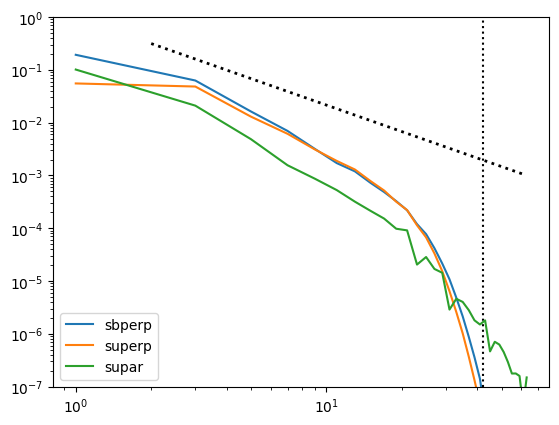

In [11]:
sk=sn.load_snapshot(6,mngr,params,shardings)
bin_factor=2
bins,su,sb=diag.perpspec(sk,kgrid,params,bin_factor=bin_factor)
plt.loglog(bins,sb,label='sbperp')
plt.loglog(bins,su,label='superp')
plt.ylim(1e-7,1)
plt.loglog(k,k**(-5.0/3.0),'k:',linewidth=2)
plt.loglog([params.nx//3,params.nx//3],[1e-7,1],'k:')
binsz,suz,sbz=diag.parspec(sk,kgrid,params,bin_factor)
plt.loglog(binsz,suz,label='supar')
#plt.loglog(kz,kz**(-5/3))
plt.legend()


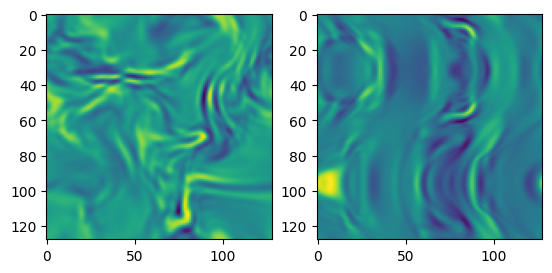

In [17]:
sk=sn.load_snapshot(6,mngr,params,shardings)
vort = ft.irfft2(-kgrid.ksq()*sk.fields.phik)
plt.subplot(121)
plt.imshow(vort[0,:,:])
plt.subplot(122)
plt.imshow(vort[:,0,:])

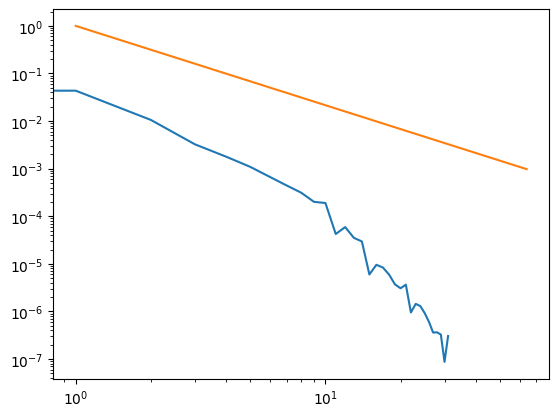

In [33]:
suz,sbz=parspec(sk,kgrid,params)
kz = ft.rfftfreq(params.nz) * params.nz * 2 * jnp.pi / params.Lz
plt.loglog(suz/nz**2)
plt.loglog(kz,kz**(-5/3))

In [11]:
phik = state.fields.phik
phikkz = ft.fft(phik,axis=0)
phi=ft.irfft2(phik)
print(jnp.sum(jnp.abs(phikkz)**2)/float(nx*ny*nz)**2, jnp.sum(phi**2)/nx/ny/nz)

0.375 0.5000000000000013


In [30]:
phi = jnp.cos(x_grid) + jnp.zeros_like(y_grid) + jnp.zeros_like(z_grid)
#phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
phik=ft.rfft2(phi)
phikkz=ft.fft(phik,axis=0)
kz=ft.fftfreq(params.nz) * params.nz * 2 * jnp.pi / params.Lz
k3dsq=kgrid.ksq().reshape(1,128,65) + (kz**2).reshape(-1,1,1)
#double_factor = jnp.where(k3dsq==0,1,2)
print(jnp.sum(phi**2)/nx/ny/nz,jnp.sum(jnp.abs(phikkz)**2 /nx**2/ny**2/nz**2))


0.5 0.5


In [22]:
jnp.shape(kgrid.ksq().reshape(1,128,65))

(1, 128, 65)